You have at your disposal 100000 images of human faces, and their occlusion label.
The goal of this challenge is to regress the percentage of the face that is occluded.
We also want to have similar performances on female and male, the gender label is given for the train database

Below is the formula of the evaluation score

$$
 Err = \frac{\sum_{i}{w_i(p_i - GT_i)^2}}{\sum_{i}{w_i}}, w_i = \frac{1}{30} + GT_i
$$

$$
Score = \frac{Err_F + Err_M}{2} + \left | Err_F - Err_M \right |
$$

In [1]:
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
from collections import OrderedDict

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

### Load dataframes

In [12]:
!ls ../crops/Crop_224_5fp_100K

database1  database2  database3


In [13]:
df_train = pd.read_csv("occlusion_datasets/train.csv", delimiter=',')
df_test = pd.read_csv("occlusion_datasets/test_students.csv", delimiter=',')

image_dir = "../crops/Crop_224_5fp_100K"

In [14]:
df_train.head()

,filename,FaceOcclusion,gender
0,database3/database3/m.01w0zk1/66-FaceId-0_alig...,0.024005,1.0
1,database3/database3/m.016ywr/88-FaceId-0_align...,0.030028,1.0
2,database3/database3/m.02dfmb/105-FaceId-0_alig...,0.009984,0.0
3,database3/database3/m.01_h_s/33-FaceId-5_align...,0.255016,1.0
4,database3/database3/m.02lqkv/85-FaceId-0_align...,0.252091,1.0


In [15]:
df_test.head()

,filename
0,database3/database3/m.0256vn/81-FaceId-0_align...
1,database3/database3/m.01dgwg/29-FaceId-0_align...
2,database3/database3/m.02l0nk/72-FaceId-0_align...
3,database3/database3/m.026jp3/94-FaceId-1_align...
4,database3/database3/m.01ncgyv/24-FaceId-0_alig...


#### Remove nan values

In [16]:
df_train = df_train.dropna()
df_test = df_test.dropna()

### Split Dataframe in train and val

In [17]:
df_val = df_train.loc[:20000].reset_index()
df_train = df_train.loc[20000:].reset_index()

In [18]:
len(df_train), len(df_val), len(df_test)

(80000, 20001, 29980)

### Check that all images are read correctly

In [19]:
for idx, row in tqdm(df_train.iterrows(), total=len(df_train)):
    try:
        filename = df_train.loc[idx, 'filename']
        img2display = Image.open(f"{image_dir}/{filename}")
    except ValueError as e:
        print(idx, e)

for idx, row in tqdm(df_val.iterrows(), total=len(df_val)):
    try:
        filename = df_val.loc[idx, 'filename']
        img2display = Image.open(f"{image_dir}/{filename}")
    except ValueError as e:
        print(idx, e)
        
for idx, row in tqdm(df_test.iterrows(), total=len(df_test)):
    try:
        filename = df_test.loc[idx, 'filename']
        img2display = Image.open(f"{image_dir}/{filename}")
    except ValueError as e:
        print(idx, e)

100%|██████████| 29980/29980 [00:09<00:00, 3091.13it/s]


### Display random images

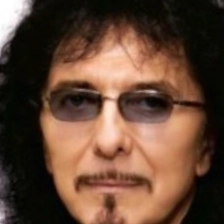

database3/database3/m.0238lz/99-FaceId-0_align.webp 0.173016 1.0


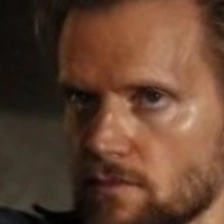

database3/database3/m.01jscz/109-FaceId-0_align.webp 0.001979 1.0


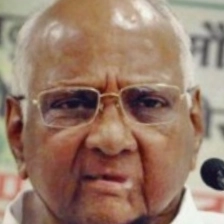

database3/database3/m.0246lq/98-FaceId-0_align.webp 0.004976 1.0


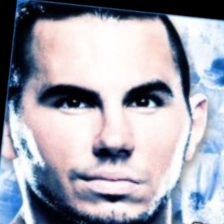

database3/database3/m.01zqb7/79-FaceId-0_align.webp 0.033836 1.0


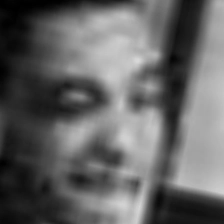

database3/database3/m.01trsrt/28-FaceId-0_align.webp 0.003955 1.0


In [20]:
for idx, row in df_train.sample(frac=1)[:5].iterrows():
    filename = row['filename']
    occlusion = row['FaceOcclusion']
    gender = row['gender']
    img2display = Image.open(f"{image_dir}/{filename}")
    display(img2display)
    print(filename, occlusion, gender)

### Make Dataset and Dataloader

In [21]:
class Dataset(torch.utils.data.Dataset):
    'Characterizes a dataset for PyTorch'
    def __init__(self, df, image_dir, training=True):
         'Initialization'
         self.training = training
         self.image_dir = image_dir
         self.df = df
         self.transform = transforms.ToTensor()
         
    def __len__(self):
        'Denotes the total number of samples'
        return len(self.df)

    def __getitem__(self, index):
        'Generates one sample of data'
        # Select sample
        row = self.df.loc[index]
        filename = row['filename']

        # Load data and get label
        img = Image.open(f"{image_dir}/{filename}")

        X = self.transform(img)

        if self.training:
            y = row['FaceOcclusion']
            y = np.float32(y)
            gender = row['gender']
            return X, y, gender, filename
        else:
            y = None
            gender = None
            return X, filename

In [22]:
training_set = Dataset(df_train, image_dir)
validation_set = Dataset(df_val, image_dir)
test_set = Dataset(df_test, image_dir, training=False)

params_train = {'batch_size': 64,
          'shuffle': True,
          'num_workers': 4}

params_val = {'batch_size': 64,
          'shuffle': False,
          'num_workers': 4}

training_generator = torch.utils.data.DataLoader(training_set, **params_train)
validation_generator = torch.utils.data.DataLoader(validation_set, **params_val)
test_generator = torch.utils.data.DataLoader(test_set, **params_val)

### Create naive model

In [23]:
from torchvision.models import mobilenet_v3_small
model = torchvision.models.mobilenet_v3_small(num_classes=1)
model

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16

#### Count number of parameters

In [24]:
from prettytable import PrettyTable

def count_parameters(model):
    table = PrettyTable(["Modules", "Parameters"])
    total_trainable_params = 0
    total_params = 0
    for name, parameter in model.named_parameters():
        params = parameter.numel()
        total_params += params
        if not parameter.requires_grad:
            continue
        table.add_row([name, params])
        total_trainable_params += params
    print(table)
    print(f"Total Trainable Params: {total_trainable_params}")
    print(f"Total Params: {total_params}")
    
count_parameters(model)

+--------------------------------+------------+
|            Modules             | Parameters |
+--------------------------------+------------+
|      features.0.0.weight       |    432     |
|      features.0.1.weight       |     16     |
|       features.0.1.bias        |     16     |
|  features.1.block.0.0.weight   |    144     |
|  features.1.block.0.1.weight   |     16     |
|   features.1.block.0.1.bias    |     16     |
| features.1.block.1.fc1.weight  |    128     |
|  features.1.block.1.fc1.bias   |     8      |
| features.1.block.1.fc2.weight  |    128     |
|  features.1.block.1.fc2.bias   |     16     |
|  features.1.block.2.0.weight   |    256     |
|  features.1.block.2.1.weight   |     16     |
|   features.1.block.2.1.bias    |     16     |
|  features.2.block.0.0.weight   |    1152    |
|  features.2.block.0.1.weight   |     72     |
|   features.2.block.0.1.bias    |     72     |
|  features.2.block.1.0.weight   |    648     |
|  features.2.block.1.1.weight   |     7

### Loss and optimizer

In [25]:
loss_fn = nn.MSELoss()

In [26]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### Train naive model

In [27]:
# CUDA for PyTorch
use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")
torch.backends.cudnn.benchmark = True

model = model.to(device)

#### Fit on train split

In [29]:
num_epochs = 1

for n in range(num_epochs):
    print(f"Epoch {n+1}")
    for batch_idx, (X, y, gender, filename) in (pbar := tqdm(enumerate(training_generator), total=len(training_generator))):
        # Transfer to GPU
        X, y = X.to(device), y.to(device)
        y = y.view(-1, 1)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)

        if loss.isnan():
            print(filename)
            print('label', y)
            print('y_pred', y_pred)
            break

        pbar.set_description(f"Loss: {loss.item():.4f}")
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        

Epoch 1


  0%|          | 0/1250 [00:15<?, ?it/s]


KeyboardInterrupt: 

## Evaluate metric on validation split

In [18]:
def error_fn(df):
    pred = df.loc[:, "pred"]
    ground_truth = df.loc[:, "target"]
    weight = 1/30 + ground_truth

    return np.sum(((pred - ground_truth)**2) * weight, axis=0) / np.sum(weight, axis=0)

def metric_fn(female, male):
    err_male = error_fn(male)
    err_female = error_fn(female)
    return (err_male + err_female) / 2 + abs(err_male - err_female)

In [19]:
results_list = []
with torch.inference_mode():
    for batch_idx, (X, y, gender, filename) in tqdm(enumerate(validation_generator), total=len(validation_generator)):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        for i in range(len(X)):

            results_list.append({'filename': filename[i],
                                 'pred': float(y_pred[i]),
                                  'target': float(y[i]),
                                  'gender': float(gender[i])
                                 })
results_df = pd.DataFrame(results_list)

100%|█████████████████████████████████████████| 313/313 [01:20<00:00,  3.90it/s]


In [20]:
results_df.head()

,filename,pred,target,gender
0,database3/database3/m.01w0zk1/66-FaceId-0_alig...,0.013374,0.024005,1.0
1,database3/database3/m.016ywr/88-FaceId-0_align...,0.033009,0.030028,1.0
2,database3/database3/m.02dfmb/105-FaceId-0_alig...,0.018109,0.009984,0.0
3,database3/database3/m.01_h_s/33-FaceId-5_align...,0.146553,0.255016,1.0
4,database3/database3/m.02lqkv/85-FaceId-0_align...,0.266857,0.252091,1.0


<Axes: >

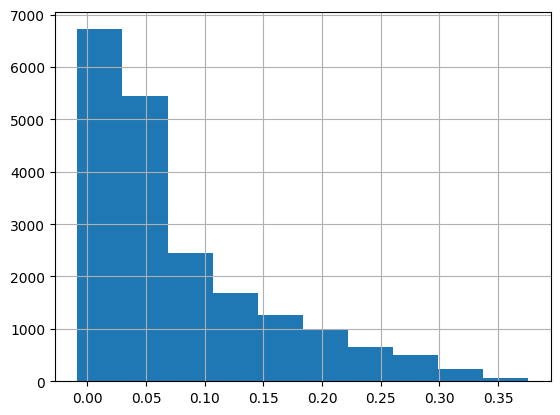

In [21]:
import matplotlib.pyplot as plt
results_df['pred'].hist()


In [22]:
results_male = results_df.loc[results_df["gender"] == 1.0]
results_female = results_df.loc[results_df["gender"] == 0.0]

In [23]:
metric_fn(results_male, results_female)

np.float64(0.00428758396351392)

### Make predictions on test dataset

In [24]:
results_list = []
with torch.inference_mode():
    for batch_idx, (X, filename) in tqdm(enumerate(test_generator), total=len(test_generator)):
        X = X.to(device)
        y_pred = model(X)
    
        for i in range(len(X)):
            results_list.append({'filename': filename[i],
                                 'FaceOcclusion': float(y_pred[i]),
                                 })
results_df = pd.DataFrame(results_list)

100%|█████████████████████████████████████████| 469/469 [01:50<00:00,  4.25it/s]


In [25]:
results_df.head()

,filename,FaceOcclusion
0,database3/database3/m.0256vn/81-FaceId-0_align...,0.134231
1,database3/database3/m.01dgwg/29-FaceId-0_align...,0.090508
2,database3/database3/m.02l0nk/72-FaceId-0_align...,0.060727
3,database3/database3/m.026jp3/94-FaceId-1_align...,0.100883
4,database3/database3/m.01ncgyv/24-FaceId-0_alig...,0.107763


### Export predictions
Note: We need to add a dummy 'gender' column for the hfactory upload.

In [26]:
results_df['gender'] = 'x'
results_df.to_csv("test_predictions.csv", sep=',', index=False)

# Pour aller plus loin

1- data augmentation
2- changer de model -> trouver le model ideal
3- 